#IMPLEMENTING A SIMPLE NEURAL NETWORK ON THE TITANIC DATASET
##1. INTRODUCTION
The Titanic dataset is one of the most well-known datasets in data science and
machine learning. It contains details of passengers aboard the RMS Titanic and
their survival status. This case study aims to build a simple neural network model
to predict whether a passenger survived the disaster based on available features.
##2. PROBLEM STATEMENT
The objective is to classify passengers as either survivors or non-survivors using a
neural network model. Given the dataset, we will preprocess the data, train a
neural network, and evaluate its performance.
##3. DATASET INFORMATION
Source:"https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

Key Features:

*   PassengerId (Unique ID of the passenger)
*   Pclass (Ticket class: 1 = First, 2 = Second, 3 = Third)
*   Name (Passenger’s name)
*   Sex (Male/Female)
*   Age (Age in years)
*   SibSp (Number of siblings/spouses aboard)
*   Parch (Number of parents/children aboard)
*   Ticket (Ticket number)
*   Fare (Ticket fare)
*   Cabin (Cabin number)
*   Embarked (Port of embarkation: C = Cherbourg, Q = Queenstown, S =
Southampton)
*   Survived (Target variable: 0 = No, 1 = Yes)

##4. DATA PREPROCESSING

In [39]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [40]:
# 2. Load Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [41]:
# 3. Data Preprocessing
# Drop unnecessary columns
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [42]:
# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_532/1230447520.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_532/1230447520.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [43]:
# Encode categorical data
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [44]:
# Features and Target
X = df.drop('Survived', axis=1)
y = df['Survived']

In [45]:
# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
# 5. Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 5. MODEL IMPLEMENTATION

In [47]:
# 6. Build Neural Network
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
# 7. Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [49]:
# 8. Train Model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5835 - loss: 0.6864 - val_accuracy: 0.7273 - val_loss: 0.6402
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6801 - loss: 0.6423 - val_accuracy: 0.7972 - val_loss: 0.5958
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7592 - loss: 0.5992 - val_accuracy: 0.8112 - val_loss: 0.5526
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7768 - loss: 0.5584 - val_accuracy: 0.8042 - val_loss: 0.5103
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7856 - loss: 0.5224 - val_accuracy: 0.8252 - val_loss: 0.4774
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7821 - loss: 0.4952 - val_accuracy: 0.7902 - val_loss: 0.4547
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8014 - loss: 0.4760 - val_accuracy: 0.7902 - val_loss: 0.4435
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8032 - loss: 0.4643 - val_accuracy: 0.7972 - val_loss:

In [50]:
# 9. Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8156 - loss: 0.4225 

Test Accuracy: 0.8156424760818481


In [51]:
# 10. Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [52]:
# 11. Metrics & Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[92 13]
 [20 54]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.88      0.85       105
           1       0.81      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179



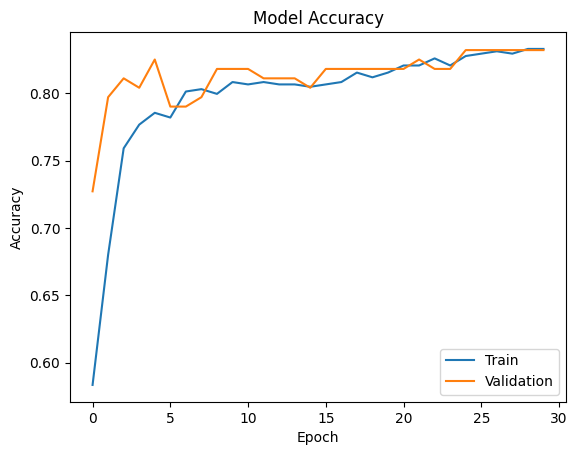

In [53]:
# Plot Training History

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

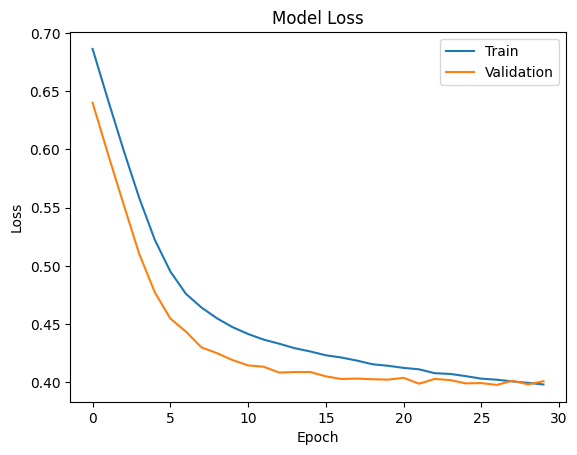

In [54]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

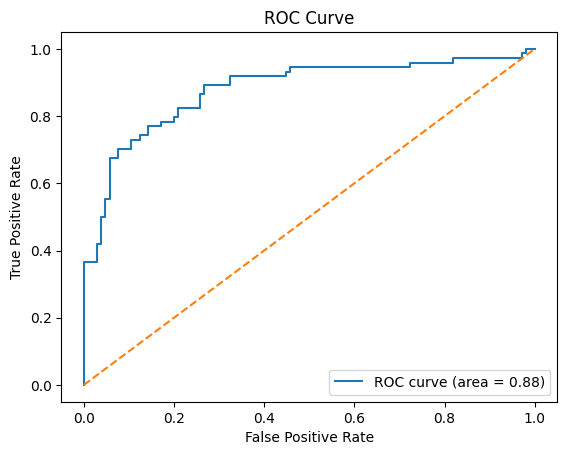

In [55]:
# 12. ROC Curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

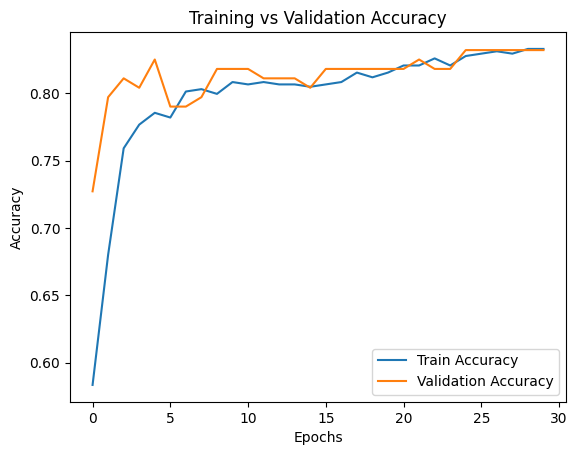

In [56]:
# 13. Training vs Validation Graph
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

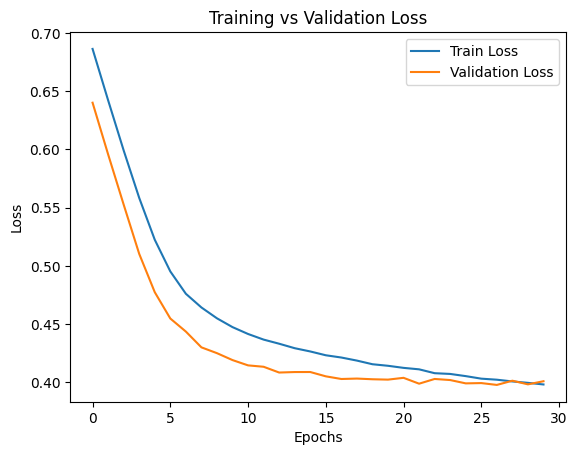

In [57]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

##6. CONCLUSION

###Key findings and model performance.

In this case study, a simple neural network model was successfully implemented to predict passenger survival using the Titanic dataset. After performing data preprocessing steps such as handling missing values, encoding categorical variables, and feature scaling, the model was trained and evaluated effectively.

The neural network achieved an accuracy of approximately 81.5%, along with a ROC-AUC score of 0.88, indicating strong classification performance. The evaluation metrics, including precision, recall, and F1-score, demonstrate that the model performs well overall, with slightly better performance in predicting non-survivors compared to survivors. The training and validation curves further confirm that the model generalizes well without significant overfitting.

### Discuss potential improvements, such as hyperparameter tuning and feature selection.

Despite the good performance, there are several areas for potential improvement:

1.   Hyperparameter Tuning: Adjusting parameters such as the number of layers, neurons, learning rate, batch size, and epochs could further enhance model performance.
2.   Feature Selection and Engineering: Introducing new features (e.g., family size, title extraction from names) or selecting the most relevant features may improve prediction accuracy.
3.   Handling Class Imbalance: Techniques such as class weighting or resampling can help improve recall for the minority class (survivors).

###Suggest further enhancements, like using more complex deep learning architectures or ensemble models.

For further enhancement, more advanced approaches can be explored:

*   Deep Learning Architectures: Using deeper neural networks or techniques like Dropout and Batch Normalization.
*   Ensemble Models: Combining multiple models such as Random Forest, Gradient Boosting, or XGBoost to achieve better performance.
*   Cross-Validation: Applying k-fold cross-validation for more robust evaluation.